In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Use PennyLane-compatible implementation
from qsvt_qiskit_pennylane import block_encode_pennylane as block_encode, pc_phase, qsvt
from qiskit.quantum_info import Operator
from inverse_matrix import InverseMatrix

scaled_inverse_matrix:
[[-0.416 -5.212j   0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j    ]
 [ 0.    +0.j     -0.813 -7.5648j  0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j    ]
 [ 0.    +0.j      0.    +0.j     -1.6582-7.7913j  0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j    ]
 [ 0.    +0.j      0.    +0.j      0.    +0.j     -2.6049-4.468j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j

/home/kohei/others/qiskit-hackathon/src/qsvt/qiskit/qsvt_qiskit_pennylane.py:98: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sqrt_I_m_ATA = sqrtm(I_m - A.conj().T @ A)
/home/kohei/others/qiskit-hackathon/src/qsvt/qiskit/qsvt_qiskit_pennylane.py:105: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sqrt_I_n_AAT = sqrtm(I_n - A @ A.conj().T)


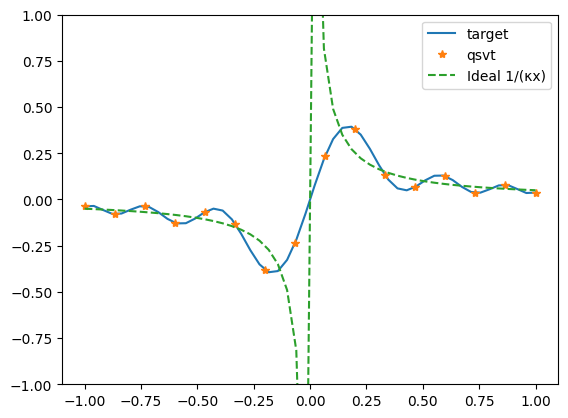

In [2]:
a_vals = np.linspace(-1, 1, 50)
# Test QSVT with matrix transformation
eigvals = np.linspace(-1, 1, 16)
A_matrix = np.diag(eigvals)  # 16-dim matrix
wire_order = list(range(5))

poly_degree = 100
kappa = 20

inverse_matrix = InverseMatrix(A_matrix, poly_degree, kappa)
_, _, _, target_poly = inverse_matrix.compute_matrix_inverse_qsvt()
qc = qsvt(
    A_matrix, target_poly, encoding_wires=wire_order, block_encoding="embedding"
)  # block-encoded in 5-qubit system

U_A = Operator(qc).data
qsvt_A = np.real(np.diagonal(U_A))[:16]  # retrieve transformed eigenvalues

target = [np.polyval(target_poly[::-1], a) for a in a_vals]
plt.plot(a_vals, target, label="target")
plt.plot(eigvals, qsvt_A, "*", label="qsvt")


# 理想関数 1/(κx)
ideal = np.zeros_like(a_vals)
mask = np.abs(a_vals) > 1e-8  # x=0 での発散を避ける
ideal[mask] = 1 / (kappa * a_vals[mask])

plt.plot(a_vals, ideal, "--", label="Ideal 1/(κx)")

plt.legend()
plt.ylim(-1,1)
plt.show()
